In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
first_invocation_bursty = 33.14

experiments = [
    {"id": "exp_20250625_014444", "name": "Openwhisk"},
    {"id": "exp_20250625_071954", "name": "Proposed"},
    {"id": "exp_20250624_210136", "name": "Histogram"},
    {"id": "exp_20250624_165438", "name": "Pagurus"},
]

aligned_results = {}
global_end_seconds = []

for exp in experiments:
    # Load function invocation trace
    fn_path = f"../results/{exp['id']}/results_updated.csv"
    fn = pd.read_csv(fn_path)
    
    # Load GPU usage trace
    gpu_path = f"../results/{exp['id']}/gpu_usage.csv"
    df = pd.read_csv(gpu_path)

    # Compute experiment-specific initial time
    first_fn_timestamp_ms = fn['timestamp'].iloc[0]
    initial_time_ms = first_fn_timestamp_ms + first_invocation_bursty * 1000

    # Parse timestamps in GPU trace
    df['datetime'] = pd.to_datetime(df['Timestamp'], unit='ms')
    df['second_level_datetime'] = df['datetime'].dt.floor('S')

    # Compute average GPU memory per container per second
    df_avg = (
        df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
          .mean()
          .reset_index()
          .rename(columns={'GPU_Memory_MB': 'Avg_GPU_Memory_MB'})
    )
    df_avg['cost_rate'] = df_avg['Avg_GPU_Memory_MB'] * COST_PER_MB_PER_SECOND

    # Aggregate cost across containers per second
    cost_per_second = (
        df_avg.groupby('second_level_datetime')['cost_rate']
              .sum()
              .reset_index(name='overall_cost')
    )

    # Compute relative seconds against initial time
    initial_datetime = pd.to_datetime(initial_time_ms, unit='ms')
    cost_per_second['relative_seconds'] = (
        (cost_per_second['second_level_datetime'] - initial_datetime)
        .dt.total_seconds()
        .astype(int)
    )

    # Filter out any negative relative seconds
    cost_per_second = cost_per_second[cost_per_second['relative_seconds'] >= 0].reset_index(drop=True)

    # Fill missing seconds to get continuous time series
    max_sec = cost_per_second['relative_seconds'].max()
    full_sec = pd.DataFrame({'relative_seconds': range(max_sec + 1)})
    cost_per_second = full_sec.merge(cost_per_second, on='relative_seconds', how='left')
    cost_per_second['overall_cost'].fillna(0, inplace=True)

    # Compute cumulative cost
    cost_per_second['cumulative_cost'] = cost_per_second['overall_cost'].cumsum()
    cost_per_second['relative_hours'] = cost_per_second['relative_seconds'] / 3600

    aligned_results[exp['name']] = cost_per_second
    global_end_seconds.append(max_sec)

# Compute common time horizon (shortest run length)
t_end = min(global_end_seconds)

# Compute global Y-axis limits
all_cum_costs = pd.concat([
    df[df['relative_seconds'] <= t_end]['cumulative_cost']
    for df in aligned_results.values()
])
global_min = all_cum_costs.min()
global_max = all_cum_costs.max()

# Plotting
plt.figure(figsize=(3.5, 2.4))
for name, df in aligned_results.items():
    df_trimmed = df[df['relative_seconds'] <= t_end]
    plt.plot(
        df_trimmed['relative_hours'],
        df_trimmed['cumulative_cost'],
        label=name,
        linewidth=1.3,
        linestyle='-',
        marker=''
    )

plt.xlabel('Elapsed Time (h)', fontsize=12, fontname='serif')
plt.ylabel('Cumulative GPU Cost ($)', fontsize=12, fontname='serif')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=8)
plt.grid(linestyle=':', linewidth=0.5, alpha=0.6)
# plt.ylim(global_min, global_max)
plt.ylim(0,1200)
plt.tight_layout(pad=0.4)
plt.show()

    

    
    

/tmp/ipykernel_1079871/3752318592.py:28: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['second_level_datetime'] = df['datetime'].dt.floor('S')


NameError: name 'COST_PER_MB_PER_SECOND' is not defined

/tmp/ipykernel_1079871/2400115977.py:24: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['second_level_datetime'] = df['datetime'].dt.floor('S')
/tmp/ipykernel_1079871/2400115977.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cost_per_second['overall_cost'].fillna(0, inplace=True)
/tmp/ipykernel_1079871/2400115977.py:24: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['second_level_datetime'] = df['datetime'].dt.

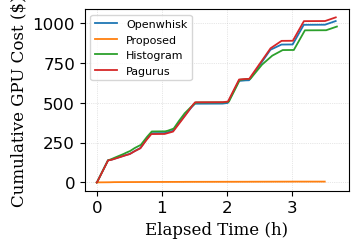

In [4]:

# 5 minutes keep alive time, brusty
# experiments = [
#     {"id": "exp_20250623_144524", "name": "Openwhisk"},
#     {"id": "exp_20250623_102900", "name": "Proposed"},
#     {"id": "exp_20250623_210541", "name": "Histogram"},
#     {"id": "exp_20250624_100734", "name": "Pagurus"},
# ]
# 10 minutes keep alive, brusty
experiments = [
    {"id": "exp_20250625_014444", "name": "Openwhisk"},
    {"id": "exp_20250625_071954", "name": "Proposed"},
    {"id": "exp_20250624_210136", "name": "Histogram"},
    {"id": "exp_20250624_165438", "name": "Pagurus"},
]
COST_PER_MB_PER_SECOND = 0.00001

plt.figure(figsize=(3.5, 2.4))

for exp in experiments:
    path = f"../results/{exp['id']}/gpu_usage.csv"
    df = pd.read_csv(path)

    df['datetime'] = pd.to_datetime(df['Timestamp'], unit='ms')
    df['second_level_datetime'] = df['datetime'].dt.floor('S')

    df_avg = (
        df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
          .mean()
          .reset_index()
          .rename(columns={'GPU_Memory_MB': 'Avg_GPU_Memory_MB'})
    )

    df_avg['cost_rate'] = df_avg['Avg_GPU_Memory_MB'] * COST_PER_MB_PER_SECOND

    cost_per_second = (
        df_avg.groupby('second_level_datetime')['cost_rate']
              .sum()
              .reset_index(name='overall_cost')
    )

    start_time = cost_per_second['second_level_datetime'].min()
    cost_per_second['relative_seconds'] = (
        cost_per_second['second_level_datetime'] - start_time
    ).dt.total_seconds().astype(int)

    max_sec = cost_per_second['relative_seconds'].max()
    full_sec = pd.DataFrame({'relative_seconds': range(max_sec + 1)})
    cost_per_second = full_sec.merge(cost_per_second, on='relative_seconds', how='left')
    cost_per_second['overall_cost'].fillna(0, inplace=True)

    cost_per_second['cumulative_cost'] = cost_per_second['overall_cost'].cumsum()
    cost_per_second['relative_hours'] = cost_per_second['relative_seconds'] / 3600

    plt.plot(
        cost_per_second['relative_hours'],
        cost_per_second['cumulative_cost'],
        label=exp['name'],
        linewidth=1.3,
        linestyle='-',
        marker=''
    )

plt.xlabel('Elapsed Time (h)', fontsize=12, fontname='serif')
plt.ylabel('Cumulative GPU Cost ($)', fontsize=12, fontname='serif')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=8)
plt.grid(linestyle=':', linewidth=0.5, alpha=0.6)
plt.tight_layout(pad=0.4)
plt.show()


In [5]:
path1 = f"../results/exp_20250625_014444/gpu_usage.csv"
tf = pd.read_csv(path1)
tf

,Timestamp,ContainerID,ImageName,GPU_Memory_MB
0,1750783539000,c1a0dd24f994,pandeymanish93/ml-inference:efficientnet-v1.0,372.0
1,1750783540000,c1a0dd24f994,pandeymanish93/ml-inference:efficientnet-v1.0,544.0
2,1750783540000,c1a0dd24f994,pandeymanish93/ml-inference:efficientnet-v1.0,1270.0
3,1750783541000,c86e45115f0f,pandeymanish93/ml-inference:efficientnet-v1.0,348.0
4,1750783541000,c1a0dd24f994,pandeymanish93/ml-inference:efficientnet-v1.0,1270.0
...,...,...,...,...
207209,1750796743000,9520be7cbadb,pandeymanish93/ml-inference:bert-v1.0,778.0
207210,1750796743000,a3f828042bb7,pandeymanish93/ml-inference:bert-v1.0,778.0
207211,1750796744000,2c864103791d,pandeymanish93/ml-inference:bert-v1.0,778.0
207212,1750796744000,6bddb13195b9,pandeymanish93/ml-inference:bert-v1.0,778.0


/tmp/ipykernel_1079871/1181806748.py:26: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['second_level_datetime'] = df['datetime'].dt.floor('S')
/tmp/ipykernel_1079871/1181806748.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cost_per_second['overall_cost'].fillna(0, inplace=True)
/tmp/ipykernel_1079871/1181806748.py:26: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['second_level_datetime'] = df['datetime'].dt.

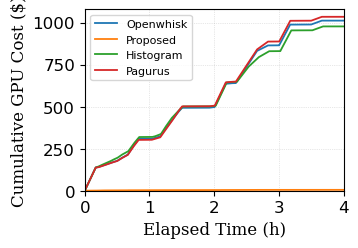

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

first_invocation_bursty = 33.14

experiments = [
    {"id": "exp_20250625_014444", "name": "Openwhisk"},
    {"id": "exp_20250625_071954", "name": "Proposed"},
    {"id": "exp_20250624_210136", "name": "Histogram"},
    {"id": "exp_20250624_165438", "name": "Pagurus"},
]

COST_PER_MB_PER_SECOND = 0.00001
aligned_results = {}

for exp in experiments:
    fn_path = f"../results/{exp['id']}/results_updated.csv"
    fn = pd.read_csv(fn_path)
    gpu_path = f"../results/{exp['id']}/gpu_usage.csv"
    df = pd.read_csv(gpu_path)

    first_fn_timestamp_ms = fn['timestamp'].iloc[0]
    initial_time_ms = first_fn_timestamp_ms + first_invocation_bursty * 1000

    df['datetime'] = pd.to_datetime(df['Timestamp'], unit='ms')
    df['second_level_datetime'] = df['datetime'].dt.floor('S')

    df_avg = (
        df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
          .mean()
          .reset_index()
          .rename(columns={'GPU_Memory_MB': 'Avg_GPU_Memory_MB'})
    )
    df_avg['cost_rate'] = df_avg['Avg_GPU_Memory_MB'] * COST_PER_MB_PER_SECOND

    cost_per_second = (
        df_avg.groupby('second_level_datetime')['cost_rate']
              .sum()
              .reset_index(name='overall_cost')
    )

    initial_datetime = pd.to_datetime(initial_time_ms, unit='ms')
    cost_per_second['relative_seconds'] = (
        (cost_per_second['second_level_datetime'] - initial_datetime)
        .dt.total_seconds()
        .astype(int)
    )

    cost_per_second = cost_per_second[cost_per_second['relative_seconds'] >= 0].reset_index(drop=True)

    max_sec = cost_per_second['relative_seconds'].max()
    full_sec = pd.DataFrame({'relative_seconds': range(max_sec + 1)})
    cost_per_second = full_sec.merge(cost_per_second, on='relative_seconds', how='left')
    cost_per_second['overall_cost'].fillna(0, inplace=True)

    cost_per_second['cumulative_cost'] = cost_per_second['overall_cost'].cumsum()
    cost_per_second['relative_hours'] = cost_per_second['relative_seconds'] / 3600

    # Padding logic: extend to full 4 hours (if not already)
    t_target_seconds = 4 * 3600
    if cost_per_second['relative_seconds'].max() < t_target_seconds:
        last_cost = cost_per_second['cumulative_cost'].iloc[-1]
        extra = pd.DataFrame({
            'relative_seconds': [t_target_seconds],
            'overall_cost': [0],
            'cumulative_cost': [last_cost],
            'relative_hours': [t_target_seconds / 3600]
        })
        cost_per_second = pd.concat([cost_per_second, extra], ignore_index=True)

    aligned_results[exp['name']] = cost_per_second

# Now plotting
plt.figure(figsize=(3.5, 2.4))
for name, df in aligned_results.items():
    plt.plot(
        df['relative_hours'],
        df['cumulative_cost'],
        label=name,
        linewidth=1.3,
        linestyle='-',
        marker=''
    )

plt.xlabel('Elapsed Time (h)', fontsize=12, fontname='serif')
plt.ylabel('Cumulative GPU Cost ($)', fontsize=12, fontname='serif')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=8)
plt.grid(linestyle=':', linewidth=0.5, alpha=0.6)
plt.ylim(0, 1080)
plt.xlim(0, 4)  # Also enforce full 4-hour x-axis
plt.tight_layout(pad=0.4)
plt.show()


In [7]:
def scientific_integer(x, pos):
    # Format without decimal points
    return f'{int(x):d}'

/tmp/ipykernel_1079871/4267648782.py:28: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['second_level_datetime'] = df['datetime'].dt.floor('S')
/tmp/ipykernel_1079871/4267648782.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cost_per_second['overall_cost'].fillna(0, inplace=True)
/tmp/ipykernel_1079871/4267648782.py:28: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['second_level_datetime'] = df['datetime'].dt.

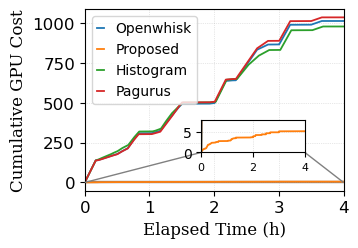

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker

first_invocation_bursty = 33.14

experiments = [
    {"id": "exp_20250625_014444", "name": "Openwhisk"},
    {"id": "exp_20250625_071954", "name": "Proposed"},
    {"id": "exp_20250624_210136", "name": "Histogram"},
    {"id": "exp_20250624_165438", "name": "Pagurus"},
]

COST_PER_MB_PER_SECOND = 0.00001
aligned_results = {}

for exp in experiments:
    fn_path = f"../results/{exp['id']}/results_updated.csv"
    fn = pd.read_csv(fn_path)
    gpu_path = f"../results/{exp['id']}/gpu_usage.csv"
    df = pd.read_csv(gpu_path)

    first_fn_timestamp_ms = fn['timestamp'].iloc[0]
    initial_time_ms = first_fn_timestamp_ms + first_invocation_bursty * 1000

    df['datetime'] = pd.to_datetime(df['Timestamp'], unit='ms')
    df['second_level_datetime'] = df['datetime'].dt.floor('S')

    df_avg = (
        df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
          .mean()
          .reset_index()
          .rename(columns={'GPU_Memory_MB': 'Avg_GPU_Memory_MB'})
    )
    df_avg['cost_rate'] = df_avg['Avg_GPU_Memory_MB'] * COST_PER_MB_PER_SECOND

    cost_per_second = (
        df_avg.groupby('second_level_datetime')['cost_rate']
              .sum()
              .reset_index(name='overall_cost')
    )

    initial_datetime = pd.to_datetime(initial_time_ms, unit='ms')
    cost_per_second['relative_seconds'] = (
        (cost_per_second['second_level_datetime'] - initial_datetime)
        .dt.total_seconds()
        .astype(int)
    )

    cost_per_second = cost_per_second[cost_per_second['relative_seconds'] >= 0].reset_index(drop=True)

    max_sec = cost_per_second['relative_seconds'].max()
    full_sec = pd.DataFrame({'relative_seconds': range(max_sec + 1)})
    cost_per_second = full_sec.merge(cost_per_second, on='relative_seconds', how='left')
    cost_per_second['overall_cost'].fillna(0, inplace=True)

    cost_per_second['cumulative_cost'] = cost_per_second['overall_cost'].cumsum()
    cost_per_second['relative_hours'] = cost_per_second['relative_seconds'] / 3600

    # Padding to full 4 hours
    t_target_seconds = 4 * 3600
    if cost_per_second['relative_seconds'].max() < t_target_seconds:
        last_cost = cost_per_second['cumulative_cost'].iloc[-1]
        extra = pd.DataFrame({
            'relative_seconds': [t_target_seconds],
            'overall_cost': [0],
            'cumulative_cost': [last_cost],
            'relative_hours': [t_target_seconds / 3600]
        })
        cost_per_second = pd.concat([cost_per_second, extra], ignore_index=True)

    aligned_results[exp['name']] = cost_per_second

# ---------- Plotting with Inset Zoom ----------
plt.figure(figsize=(3.5, 2.4))
ax = plt.gca()

for name, df in aligned_results.items():
    ax.plot(
        df['relative_hours'],
        df['cumulative_cost'],
        label=name,
        linewidth=1.3,
        linestyle='-',
        marker=''
    )

# Apply scientific notation to x-axis
# ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))  # tick every 0.5 hours


plt.xlabel('Elapsed Time (h)', fontsize=12, fontname='serif')
plt.ylabel('Cumulative GPU Cost', fontsize=12, fontname='serif')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=10,handlelength=0.5)
plt.grid(linestyle=':', linewidth=0.5, alpha=0.6)
# plt.ylim(0, 1200)
plt.xlim(0, 4)
plt.tight_layout(pad=0.4)

# Create inset zoom plot
# axins = inset_axes(ax, width="40%", height="40%", loc='upper left', borderpad=1.2)
axins = inset_axes(ax, width="80%", height="30%", 
                   bbox_to_anchor=(0.4, 0.001, 0.5, 0.6), 
                   bbox_transform=ax.transAxes, 
                   loc='center')

for name, df in aligned_results.items():
    axins.plot(df['relative_hours'], df['cumulative_cost'],
                label=name, linewidth=1.3, linestyle='-', marker='')
# Zoom-in region for Proposed (lower range)
axins.set_xlim(0, 4)
axins.set_ylim(0, 8)  # adjust based on your actual Proposed cost
axins.grid(linestyle=':', linewidth=0.5, alpha=0.6)
plt.xticks(fontsize=8)
# ax.ticklabel_format(axis='x', style='sci', scilimits=(-1,1))


from mpl_toolkits.axes_grid1.inset_locator import mark_inset
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.5")

# plt.savefig('graphs_images/gpu_cost1.jpg', dpi=300)  # If using PIL backend

plt.show()


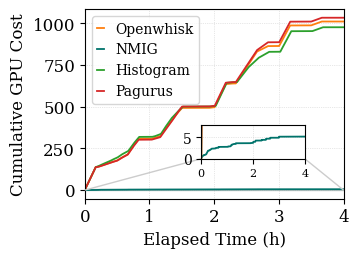

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import matplotlib as mpl

first_invocation_bursty = 33.14
mpl.rcParams['font.family'] = 'DejaVu Serif'
experiments = [
    {"id": "exp_20250625_014444", "name": "Openwhisk"},
    {"id": "exp_20250625_071954", "name": "NMIG"},
    {"id": "exp_20250624_210136", "name": "Histogram"},
    {"id": "exp_20250624_165438", "name": "Pagurus"},
]

color_map = {
    "NMIG": "#00736b",
    "Openwhisk": "#ff7f0e",
    "Histogram": "#2ca02c",
    "Pagurus": "#d62728"
}


COST_PER_MB_PER_SECOND = 0.00001
aligned_results = {}

for exp in experiments:
    fn_path = f"../results/{exp['id']}/results_updated.csv"
    fn = pd.read_csv(fn_path)
    gpu_path = f"../results/{exp['id']}/gpu_usage.csv"
    df = pd.read_csv(gpu_path)

    first_fn_timestamp_ms = fn['timestamp'].iloc[0]
    initial_time_ms = first_fn_timestamp_ms + first_invocation_bursty * 1000

    df['datetime'] = pd.to_datetime(df['Timestamp'], unit='ms')
    df['second_level_datetime'] = df['datetime'].dt.floor('s')


    df_avg = (
        df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
          .mean()
          .reset_index()
          .rename(columns={'GPU_Memory_MB': 'Avg_GPU_Memory_MB'})
    )
    df_avg['cost_rate'] = df_avg['Avg_GPU_Memory_MB'] * COST_PER_MB_PER_SECOND

    cost_per_second = (
        df_avg.groupby('second_level_datetime')['cost_rate']
              .sum()
              .reset_index(name='overall_cost')
    )

    initial_datetime = pd.to_datetime(initial_time_ms, unit='ms')
    cost_per_second['relative_seconds'] = (
        (cost_per_second['second_level_datetime'] - initial_datetime)
        .dt.total_seconds()
        .astype(int)
    )

    cost_per_second = cost_per_second[cost_per_second['relative_seconds'] >= 0].reset_index(drop=True)

    max_sec = cost_per_second['relative_seconds'].max()
    full_sec = pd.DataFrame({'relative_seconds': range(max_sec + 1)})
    cost_per_second = full_sec.merge(cost_per_second, on='relative_seconds', how='left')
    # cost_per_second['overall_cost'].fillna(0, inplace=True)
    cost_per_second['overall_cost'] = cost_per_second['overall_cost'].fillna(0)


    cost_per_second['cumulative_cost'] = cost_per_second['overall_cost'].cumsum()
    cost_per_second['relative_hours'] = cost_per_second['relative_seconds'] / 3600

    # Padding to full 4 hours
    t_target_seconds = 4 * 3600
    if cost_per_second['relative_seconds'].max() < t_target_seconds:
        last_cost = cost_per_second['cumulative_cost'].iloc[-1]
        extra = pd.DataFrame({
            'relative_seconds': [t_target_seconds],
            'overall_cost': [0],
            'cumulative_cost': [last_cost],
            'relative_hours': [t_target_seconds / 3600]
        })
        cost_per_second = pd.concat([cost_per_second, extra], ignore_index=True)

    aligned_results[exp['name']] = cost_per_second

# ---------- Plotting with Inset Zoom ----------
plt.figure(figsize=(3.5, 2.5))
ax = plt.gca()

for name, df in aligned_results.items():
    ax.plot(
        df['relative_hours'],
        df['cumulative_cost'],
        label=name,
        linewidth=1.3,
        linestyle='-',
        color=color_map.get(name, 'black'),  # unified colors
        marker=''
    )

# Apply scientific notation to x-axis
# ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))  # tick every 0.5 hours


plt.xlabel('Elapsed Time (h)', fontsize=12)
plt.ylabel('Cumulative GPU Cost', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=10,handlelength=0.5)
plt.grid(linestyle=':', linewidth=0.5, alpha=0.6)
# plt.ylim(0, 1200)
plt.xlim(0, 4)
plt.tight_layout(pad=0.4)

# Create inset zoom plot
# axins = inset_axes(ax, width="40%", height="40%", loc='upper left', borderpad=1.2)
axins = inset_axes(ax, width="80%", height="30%", 
                   bbox_to_anchor=(0.4, 0.001, 0.5, 0.6), 
                   bbox_transform=ax.transAxes, 
                   loc='center')

for name, df in aligned_results.items():
    axins.plot(
        df['relative_hours'],
        df['cumulative_cost'],
        label=name,
        linewidth=1.3,
        linestyle='-',
        color=color_map.get(name, 'black'),
        marker=''
    )
# Zoom-in region for Proposed (lower range)
axins.set_xlim(0, 4)
axins.set_ylim(0, 8)  # adjust based on your actual Proposed cost
axins.grid(linestyle=':', linewidth=0.5, alpha=0.6)
plt.xticks(fontsize=8)
# ax.ticklabel_format(axis='x', style='sci', scilimits=(-1,1))


from mpl_toolkits.axes_grid1.inset_locator import mark_inset
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.8")

plt.savefig('graphs_images/gpu_cost_bursty.jpg', dpi=300)  # If using PIL backend

plt.show()


In [10]:
result_all = {key: df["cumulative_cost"].max() for key, df in aligned_results.items()}
result_all

{'Openwhisk': 1011.5410599999354,
 'NMIG': 5.185870000000003,
 'Histogram': 977.1094999999921,
 'Pagurus': 1034.2575599999857}

In [4]:
import pandas as pd
import numpy as np

# ---- point this at whichever dataset you're processing ----
first_invocation_bursty = 33.14
experiments = [
    {"id": "exp_20250625_014444", "name": "Openwhisk"},
    {"id": "exp_20250625_071954", "name": "NMIG"},
    {"id": "exp_20250624_210136", "name": "Histogram"},
    {"id": "exp_20250624_165438", "name": "Pagurus"},
]



COST_PER_MB_PER_SECOND = 0.00001
T_TARGET = 4 * 3600

summary = {}

for exp in experiments:
    fn = pd.read_csv(f"../results/{exp['id']}/results_updated.csv")
    df = pd.read_csv(f"../results/{exp['id']}/gpu_usage.csv")

    initial_time_ms = fn['timestamp'].iloc[0] + first_invocation_time * 1000
    df['second_level_datetime'] = pd.to_datetime(df['Timestamp'], unit='ms').dt.floor('s')

    # avg resident GPU memory per container per second, then summed across containers
    df_avg = (df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
                .mean().reset_index())
    mem_per_second = (df_avg.groupby('second_level_datetime')['GPU_Memory_MB']
                            .sum().reset_index(name='total_mem_mb'))

    initial_dt = pd.to_datetime(initial_time_ms, unit='ms')
    mem_per_second['rel_s'] = ((mem_per_second['second_level_datetime'] - initial_dt)
                               .dt.total_seconds().astype(int))
    mem_per_second = mem_per_second[mem_per_second['rel_s'] >= 0].reset_index(drop=True)

    # fill every second to T_TARGET so all runs share one horizon
    full = pd.DataFrame({'rel_s': range(T_TARGET + 1)})
    m = full.merge(mem_per_second[['rel_s', 'total_mem_mb']], on='rel_s', how='left')
    m['total_mem_mb'] = m['total_mem_mb'].fillna(0)

    # --- the three metrics, all from the same series ---
    gpu_mem_seconds_mb_s = m['total_mem_mb'].sum()          # MB·s
    gpu_mem_seconds_gb_s = gpu_mem_seconds_mb_s / 1024.0    # GB·s  (resource metric)
    total_cost = gpu_mem_seconds_mb_s * COST_PER_MB_PER_SECOND  # $ (your existing metric)
    mean_resident_mb = m['total_mem_mb'].mean()             # avg held memory
    peak_resident_mb = m['total_mem_mb'].max()              # peak held memory
    # idle-memory share: fraction of GPU-mem-seconds while no inference is active
    # (only meaningful if you can mark active seconds; see note below)

    summary[exp['name']] = {
        'GPU-mem-seconds (GB·s)': gpu_mem_seconds_gb_s,
        'GPU cost ($)': total_cost,
        'Mean resident GPU mem (MB)': mean_resident_mb,
        'Peak resident GPU mem (MB)': peak_resident_mb,
    }

summary_df = pd.DataFrame(summary).T
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
print(summary_df, '\n')

# reduction of NMIG vs each baseline, per metric — paste these into the paper
nmig = summary['NMIG']
for metric in summary_df.columns:
    print(f'\n{metric}:')
    for name in summary:
        if name == 'NMIG':
            continue
        base = summary[name][metric]
        red = (base - nmig[metric]) / base * 100 if base else float('nan')
        print(f'  vs {name:10s}: {red:6.2f}% reduction  (NMIG {nmig[metric]:,.3f} vs {base:,.3f})')

           GPU-mem-seconds (GB·s)  GPU cost ($)  Mean resident GPU mem (MB)  \
Openwhisk              98,869.659     1,012.425                   7,030.243   
NMIG                      529.870         5.426                      37.677   
Histogram              95,494.407       977.863                   6,790.242   
Pagurus               101,124.114     1,035.511                   7,190.549   

           Peak resident GPU mem (MB)  
Openwhisk                  22,910.000  
NMIG                       11,071.000  
Histogram                  22,928.000  
Pagurus                    22,884.000   


GPU-mem-seconds (GB·s):
  vs Openwhisk :  99.46% reduction  (NMIG 529.870 vs 98,869.659)
  vs Histogram :  99.45% reduction  (NMIG 529.870 vs 95,494.407)
  vs Pagurus   :  99.48% reduction  (NMIG 529.870 vs 101,124.114)

GPU cost ($):
  vs Openwhisk :  99.46% reduction  (NMIG 5.426 vs 1,012.425)
  vs Histogram :  99.45% reduction  (NMIG 5.426 vs 977.863)
  vs Pagurus   :  99.48% reduction  (NMIG 5.

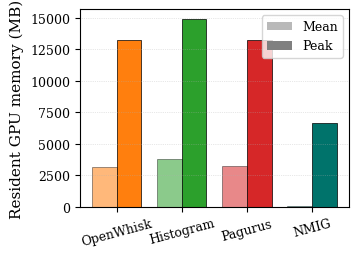

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Serif'

# mean and peak resident GPU memory (MB), normal dataset
# rows: systems; reuse your printed numbers
systems = ['OpenWhisk', 'Histogram', 'Pagurus', 'NMIG']
mean_mb = [3197.298, 3805.812, 3246.038, 31.849]
peak_mb = [13254.0, 14952.0, 13254.0, 6623.0]

color_map = {'NMIG': '#00736b', 'OpenWhisk': '#ff7f0e',
             'Histogram': '#2ca02c', 'Pagurus': '#d62728'}
colors = [color_map[s] for s in systems]

x = np.arange(len(systems))
w = 0.38

fig, ax = plt.subplots(figsize=(3.5, 2.5))
b1 = ax.bar(x - w/2, mean_mb, w, label='Mean', color=colors, alpha=0.55,
            edgecolor='black', linewidth=0.5)
b2 = ax.bar(x + w/2, peak_mb, w, label='Peak', color=colors, alpha=1.0,
            edgecolor='black', linewidth=0.5)

ax.set_ylabel('Resident GPU memory (MB)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(systems, fontsize=9, rotation=15)
ax.tick_params(axis='y', labelsize=9)
ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.6)

# distinguish mean (light) vs peak (solid) in legend without color confusion
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='gray', alpha=0.55, label='Mean'),
                   Patch(facecolor='gray', alpha=1.0, label='Peak')],
          fontsize=9, loc='upper right')

plt.tight_layout(pad=0.4)
plt.savefig('graphs_images/resident_mem_mean_peak.jpg', dpi=300)
plt.show()